# Proyecto: Análisis Exploratorio de Datos (EDA) - <BR> Campaña de Marketing Bancario

**Objetivo:** Analizar los datos de una campaña telefónica de marketing directo de una institución bancaria para entender el perfil de los clientes y los factores que influyen en la contratación de un depósito a plazo fijo.

## 1. Carga e Integración de Datos
En esta primera fase, importaremos las librerías necesarias y unificaremos la información de los clientes (dividida en varios años) con los resultados de la campaña bancaria.

In [4]:
# Importación de librerías base según el temario
import pandas as pd
import numpy as np

# 1. Cargar los detalles de clientes desde las distintas pestañas del Excel
df_2012 = pd.read_excel('../datos/customer-details.xlsx', sheet_name='2012')
df_2013 = pd.read_excel('../datos/customer-details.xlsx', sheet_name='2013')
df_2014 = pd.read_excel('../datos/customer-details.xlsx', sheet_name='2014')

# 2. Unificar los tres años en un solo DataFrame de clientes
df_clientes = pd.concat([df_2012, df_2013, df_2014], ignore_index=True)

# 3. Cargar los datos de la campaña del banco
df_banco = pd.read_csv('../datos/bank-additional.csv')

# 4. Cruzar (Merge) ambos datasets usando el identificador único
df_final = pd.merge(df_banco, df_clientes, left_on='id_', right_on='ID', how='inner')

print(f"Datos cargados y unificados. Dimensiones iniciales: {df_final.shape}")

# 5. Mostrar las primeras 5 filas para comprobar que todo esté correcto
df_final.head(5)

Datos cargados y unificados. Dimensiones iniciales: (43000, 31)


,Unnamed: 0_x,age,job,marital,education,default,housing,loan,contact,duration,...,latitude,longitude,id_,Unnamed: 0_y,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


## 2. Transformación, Limpieza e Ingeniería de Variables

Antes de analizar los datos, es necesario procesarlos para garantizar su calidad estadística. El proceso se ha estructurado en los siguientes pasos:

1. **Exploración Inicial:** Comprobación del volumen de valores nulos y los tipos de datos asignados automáticamente por Pandas.
2. **Limpieza Estructural:** Eliminación de columnas redundantes o sin valor analítico (como índices de importación) y estandarización de los nombres de las cabeceras.
3. **Corrección de Formatos Numéricos:** Transformación de las columnas numéricas afectadas por el uso europeo de comas decimales, convirtiéndolas al formato `float` estándar.
4. **Justificación de la Estrategia de Limpieza de Datos (Valores Nulos):**
   Para garantizar la integridad del análisis estadístico y evitar sesgos, se ha evitado la eliminación masiva de filas (`dropna` generalizado), aplicando en su lugar una estrategia de imputación adaptada a la naturaleza de cada variable:
   - **4.1 Variables Categóricas de Perfil (`job`, `marital`, `education`):** Se han rellenado los valores nulos con la etiqueta `'unknown'`. En el contexto del marketing bancario, la negativa de un cliente a proporcionar ciertos datos demográficos es información valiosa en sí misma y conforma un perfil específico. Borrar estos registros habría supuesto una pérdida injustificada del resto de sus datos.
   - **4.2 Variables Numéricas Continuas (`age`, `euribor3m`, `cons_price_idx`):** Se han imputado utilizando la **mediana**. Al contrario que la media, la mediana es una medida de tendencia central robusta frente a valores atípicos (*outliers*), lo que asegura que no distorsionamos la distribución real de los datos.
   - **4.3 Variables Binarias / Financieras (`default`, `housing`, `loan`):** Al tratarse de indicadores (Sí/No), se ha aplicado la imputación por la **moda** (el valor más frecuente), asumiendo el comportamiento mayoritario de la cartera de clientes.
   - **4.4 Variable Temporal (`date`):** Se ha optado por eliminar únicamente las filas sin fecha (248 registros). Al representar menos del 0.6% de la muestra, la pérdida de información es estadísticamente insignificante. Por el contrario, imputar fechas artificiales habría corrompido la estructura temporal, impidiendo un análisis fiable de la estacionalidad de las campañas.
5. **Feature Engineering (NumPy):** Creación de una nueva variable categórica (`rango_edad`) a partir de la edad continua para facilitar la segmentación generacional en el análisis posterior.

In [5]:
# --- PASO 1: EXPLORACIÓN INICIAL ---
print("--- VALORES NULOS POR COLUMNA ---")
valores_nulos = df_final.isnull().sum()
print(valores_nulos[valores_nulos > 0])

print("\n--- TIPOS DE DATOS ---")
print(df_final.dtypes)

# --- PASO 2: LIMPIEZA ESTRUCTURAL ---
df_final = df_final.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y', 'ID'])
df_final.columns = df_final.columns.str.replace('.', '_', regex=False)

# --- PASO 3: CORRECCIÓN DE FORMATOS NUMÉRICOS ---
columnas_con_coma = ['cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']
df_final[columnas_con_coma] = df_final[columnas_con_coma].apply(
    lambda x: pd.to_numeric(x.astype(str).str.replace(',', '.'), errors='coerce')
)

# --- PASO 4: IMPUTACIÓN ESTRATÉGICA DE NULOS ---
# 4.1 Categóricas de Perfil (Rellenar con 'unknown')
df_final.update(df_final[['job', 'marital', 'education']].fillna('unknown'))

# 4.2 Numéricas Continuas (Rellenar con la mediana)
cols_numericas = ['age', 'euribor3m', 'cons_price_idx']
df_final.update(df_final[cols_numericas].fillna(df_final[cols_numericas].median()))

# 4.3 Variables Binarias / Financieras (Rellenar con la moda)
cols_binarias = ['default', 'housing', 'loan']
df_final.update(df_final[cols_binarias].fillna(df_final[cols_binarias].mode().iloc[0]))

# 4.4 Variable Temporal (Eliminar filas sin fecha)
df_final = df_final.dropna(subset=['date'])

# --- PASO 5: FEATURE ENGINEERING CON NUMPY ---
condiciones = [
    (df_final['age'] < 30),
    (df_final['age'] >= 30) & (df_final['age'] <= 50),
    (df_final['age'] > 50)
]
etiquetas = ['Joven (<30)', 'Adulto (30-50)', 'Senior (>50)']
df_final['rango_edad'] = np.select(condiciones, etiquetas, default='Desconocido')

# --- COMPROBACIÓN FINAL ---
print(f"\nLimpieza completada. Nulos restantes: {df_final.isnull().sum().sum()}")

--- VALORES NULOS POR COLUMNA ---
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
cons.price.idx     471
euribor3m         9256
date               248
dtype: int64

--- TIPOS DE DATOS ---
Unnamed: 0_x                  int64
age                         float64
job                          object
marital                      object
education                    object
default                     float64
housing                     float64
loan                        float64
contact                      object
duration                      int64
campaign                      int64
pdays                         int64
previous                      int64
poutcome                     object
emp.var.rate                float64
cons.price.idx               object
cons.conf.idx                object
euribor3m                    object
nr.employed                  object
y              

## 3. Análisis Descriptivo de los Datos

Una vez consolidado y limpiado el conjunto de datos, procedemos a extraer las métricas estadísticas básicas utilizando operaciones vectorizadas de Pandas. El objetivo de esta fase es generar las tablas de frecuencias y medidas de tendencia central que servirán como base para nuestro análisis.

6. **Cálculo de Estadísticos Globales:** Obtención de distribuciones para variables continuas y categóricas.
7. **Frecuencias de la Variable Objetivo:** Medición exacta de la tasa de conversión de la campaña bancaria.

In [6]:
# --- PASO 6: CÁLCULO DE ESTADÍSTICOS GLOBALES ---
print("--- RESUMEN VARIABLES NUMÉRICAS ---")
display(df_final.describe().round(2))

print("\n--- RESUMEN VARIABLES CATEGÓRICAS ---")
display(df_final.describe(include=['object']).T)

# --- PASO 7: FRECUENCIAS DE LA VARIABLE OBJETIVO ---
print("\n--- TASA DE ÉXITO DE LA CAMPAÑA ('y') ---")
exito_campana = df_final['y'].value_counts(normalize=True) * 100
display(exito_campana.round(2).astype(str) + ' %')

--- RESUMEN VARIABLES NUMÉRICAS ---


,age,default,housing,loan,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,latitude,longitude,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752.00,42752,42752.00
mean,39.75,0.00,0.55,0.15,257.77,2.57,962.37,0.17,0.08,93.58,-40.51,3.88,5166.87,36.86,-95.94,93225.59,1.01,1.00,2013-05-12 02:36:15.224550912,16.59
min,17.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60,24.40,-125.00,5841.00,0.00,0.00,2012-01-01 00:00:00,1.00
25%,33.00,0.00,0.00,0.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.48,5099.10,30.62,-110.49,49587.50,0.00,0.00,2012-07-16 00:00:00,9.00
50%,38.00,0.00,1.00,0.00,179.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00,36.76,-95.90,93016.00,1.00,1.00,2013-03-02 00:00:00,17.00
75%,46.00,0.00,1.00,0.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10,43.11,-81.44,136732.00,2.00,2.00,2014-03-29 00:00:00,25.00
max,98.00,1.00,1.00,1.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10,49.38,-66.94,180802.00,2.00,2.00,2014-12-31 00:00:00,32.00
std,9.82,0.01,0.50,0.36,258.78,2.77,187.15,0.50,1.57,0.58,4.64,1.62,72.39,7.23,16.75,50495.80,0.82,0.82,NaN,9.24



--- RESUMEN VARIABLES CATEGÓRICAS ---


,count,unique,top,freq
job,42752,12,admin.,10802
marital,42752,4,MARRIED,25840
education,42752,8,university.degree,12642
contact,42752,2,cellular,27232
poutcome,42752,3,NONEXISTENT,36883
y,42752,2,no,37941
date,42752,1825,28-febrero-2018,95
id_,42752,42752,559a136c-781b-4a6e-b9c6-dc5c5adfec6d,1
rango_edad,42752,3,Adulto (30-50),30990



--- TASA DE ÉXITO DE LA CAMPAÑA ('y') ---


y
no     88.75 %
yes    11.25 %
Name: proportion, dtype: object

## 4. Visualización de Datos y Extracción de Insights

En esta fase del análisis exploratorio (EDA), cruzaremos nuestras variables descriptivas con la variable objetivo (`y`: éxito de la campaña) para descubrir qué perfiles son más propensos a contratar el depósito bancario. 

Para enriquecer el análisis, combinaremos distribuciones continuas (usando **Seaborn**) con agrupaciones discretas (usando el motor nativo de **Pandas**).

### 4.1. Análisis Demográfico: El factor Edad

Comenzamos evaluando el impacto de la edad en la decisión de contratación. Para interpretar correctamente los gráficos, debemos diferenciar entre el volumen total de llamadas y la probabilidad real de éxito:

* **Métricas Clave:** La edad media de los clientes contactados se sitúa en los **39.75** años. El 50% central de la muestra (rango intercuartílico) es muy compacto y se concentra entre los **33** y los **46** años.
* **Insight de Volumen Absoluto:** Al observar el histograma (izq.), confirmamos que el grueso del esfuerzo comercial del banco se ha centrado masivamente en llamar a adultos de mediana edad (30 a 50 años). Por pura estadística, la mayor cantidad total de "Síes" viene de este grupo.
* **Insight de Tasa de Conversión:** Sin embargo, el gráfico de barras apiladas (der.) nos revela un patrón crucial. Aunque los segmentos periféricos (los menores de 30 años y los mayores de 50) recibieron muchas menos llamadas, **la proporción de color verde ("Sí") dentro de sus barras es mucho mayor**. Esto indica que los jóvenes y los seniors son nichos poblacionales mucho más receptivos y rentables para este producto financiero.

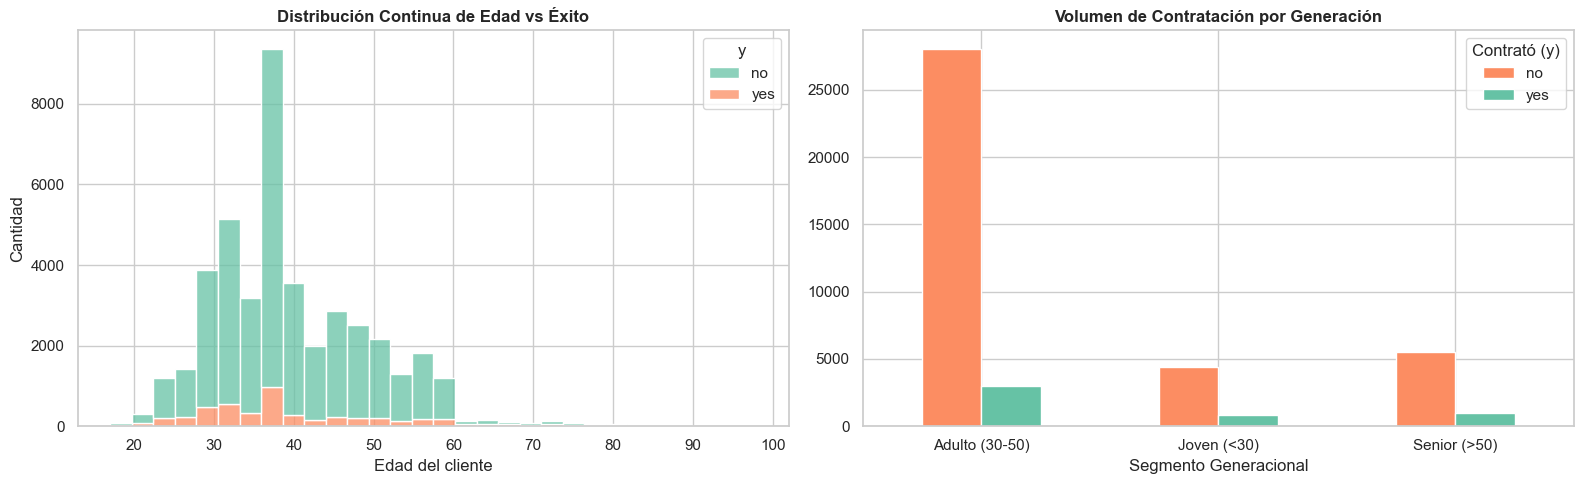

In [7]:
# --- 4.1 GRÁFICOS DEMOGRÁFICOS (EDAD) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A (Seaborn): Distribución continua
sns.histplot(data=df_final, x='age', hue='y', multiple='stack', bins=30, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución Continua de Edad vs Éxito', fontweight='bold')
axes[0].set_xlabel('Edad del cliente')
axes[0].set_ylabel('Cantidad')

# Gráfico B (Pandas): Agrupación por la variable de NumPy (rango_edad)
crosstab_edad = pd.crosstab(df_final['rango_edad'], df_final['y'])
crosstab_edad.plot(kind='bar', color=['#fc8d62', '#66c2a5'], ax=axes[1])
axes[1].set_title('Volumen de Contratación por Generación', fontweight='bold')
axes[1].set_xlabel('Segmento Generacional')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Contrató (y)')

plt.tight_layout()
plt.show()

### 4.2. Análisis Socioeconómico: El impacto de la Profesión

Una vez analizada la edad, evaluamos el impacto del sector laboral aplicando la misma distinción entre volumen y rentabilidad:

* **Métricas Clave:** El mercado principal de la campaña corresponde al perfil **administrativo** (`admin.`), representando a la gran mayoría de la muestra con **10.802** clientes. Asimismo, comprobamos que el ingreso medio (`Income`) general se ubica en torno a los **93.225** euros.
* **Insight de Volumen Absoluto:** El gráfico de ranking horizontal (izq.) nos muestra rápidamente que el sector administrativo y el de servicios aportan el mayor volumen total de contratos firmados, simplemente porque son los grupos más grandes de la base de datos.
* **Insight de Tasa de Conversión:** No obstante, al visualizar la proporción real en las barras apiladas (der.), descubrimos áreas de oportunidad de alto valor. Sectores minoritarios en volumen, como los estudiantes (`student`) y los jubilados (`retired`), muestran una franja verde ("Sí") excepcionalmente ancha en relación al tamaño de su barra. Esto corrobora el hallazgo de la variable edad: los clientes fuera del mercado laboral activo tradicional tienen una probabilidad de conversión altísima.

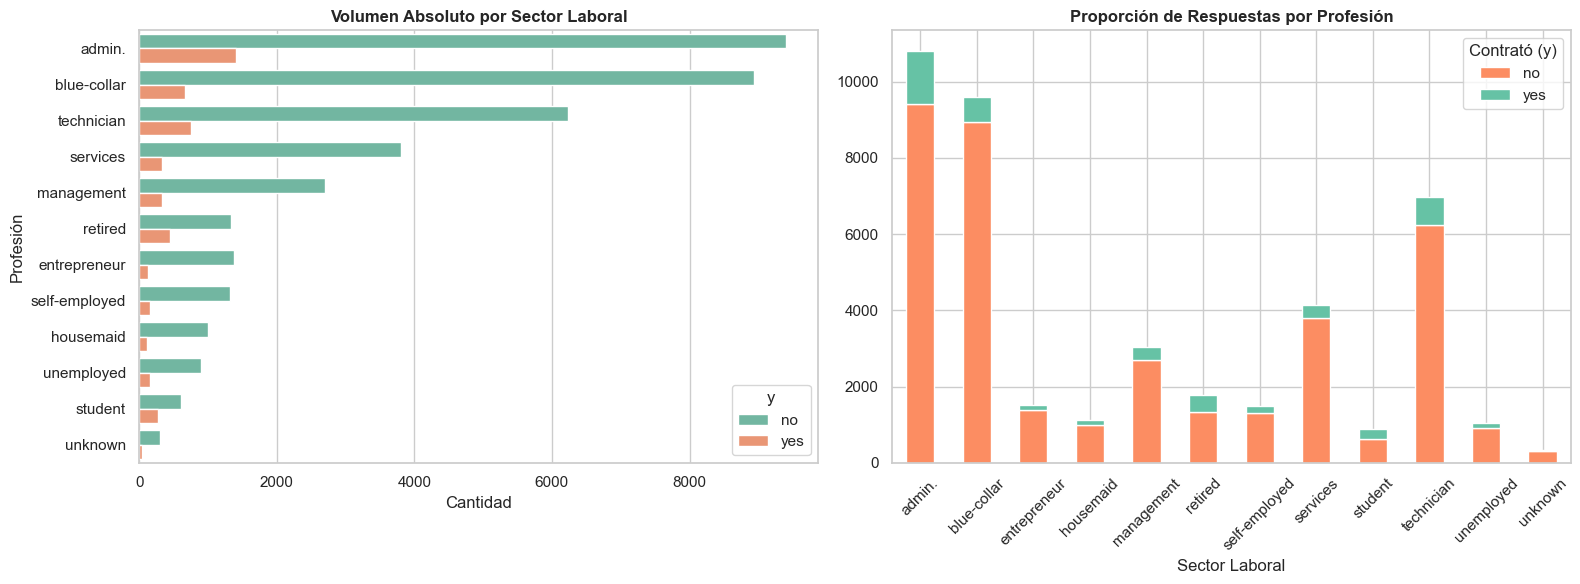

In [8]:
# --- 4.2 GRÁFICOS SOCIOECONÓMICOS (PROFESIÓN) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A (Seaborn): Ranking absoluto por profesión
sns.countplot(data=df_final, y='job', hue='y', ax=axes[0], palette='Set2', order=df_final['job'].value_counts().index)
axes[0].set_title('Volumen Absoluto por Sector Laboral', fontweight='bold')
axes[0].set_xlabel('Cantidad')
axes[0].set_ylabel('Profesión')

# Gráfico B (Pandas): Barras apiladas para ver la proporción real de éxito
crosstab_job = pd.crosstab(df_final['job'], df_final['y'])
crosstab_job.plot(kind='bar', stacked=True, color=['#fc8d62', '#66c2a5'], ax=axes[1])
axes[1].set_title('Proporción de Respuestas por Profesión', fontweight='bold')
axes[1].set_xlabel('Sector Laboral')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Contrató (y)')

plt.tight_layout()
plt.show()

### 4.3. Conclusión Comercial y Eficacia Global

Como nota final al análisis visual de todas las gráficas anteriores (dominadas por la negativa a contratar), debemos recalcar la naturaleza de los resultados de esta campaña. 

Nos enfrentamos a un escenario comercial donde el **88.75%** de los clientes contactados rechazó la propuesta, frente a un **11.25%** que aceptó. Esta baja tasa de conversión global demuestra que la estrategia de llamadas masivas indiscriminadas es ineficiente. 

Gracias a este Análisis Exploratorio de Datos (EDA), podemos concluir firmemente que el banco debería cambiar su estrategia comercial: en lugar de gastar la mayor parte de sus recursos llamando al sector mayoritario (adultos de mediana edad en el sector administrativo), debería segmentar sus futuras campañas para enfocarse en los nichos de alto valor descubiertos en este estudio (clientes jóvenes, seniors, estudiantes y jubilados), optimizando así su tasa de éxito y rentabilidad.